# **Project: Characterization of Metaheuristic Algorithms via SVD**

## **1. Abstract**
This project serves as a practical, mini-implementation of the methodology described in the 2023 IEEE paper *"Characterization of CEC Single-Objective Optimization Competition Benchmarks and Algorithms."* The primary goal is not to find the single "best" algorithm, but to automatically characterize and cluster a diverse set of metaheuristic algorithms based on their real-world performance.

We execute a suite of **eight** algorithms (Classical, Hybrid, and Swarm-based) on **five** complex benchmark functions (Ackley, Rastrigin, Sphere, Rosenbrock, Griewank). We then replicate the paper's analysis pipeline:

1.  Generate a **Performance Matrix (P)** from the results.
2.  Convert to a **Rank Matrix (R)** to normalize performance.
3.  Apply **Singular Value Decomposition (SVD)** to extract latent "behavioral features."
4.  Use **Hierarchical Clustering** on these features to visualize which algorithms solve problems in the most similar way.

This demonstrates an effective, data-driven approach to understanding algorithm relationships beyond their original designs.

---

## **2. Methodology**
The analysis pipeline consists of five distinct stages, moving from algorithm execution to final analysis.

### **2.1. The Test Bed**

**Algorithms:** A diverse suite of 8 metaheuristics was chosen:
* **PSO** (Particle Swarm Optimization)
* **DE** (Differential Evolution)
* **GA** (Genetic Algorithm)
* **SA** (Simulated Annealing)
* **H-PSO-GA** (Hybrid PSO-GA)
* **C-Bat** (Chaotic Bat Algorithm)
* **FA** (Firefly Algorithm)
* **GWO** (Grey Wolf Optimizer)

**Benchmarks:** A set of 5 standard, multi-dimensional optimization functions were used:
* **Sphere Function:** Unimodal and convex.
* **Ackley Function:** Multi-modal with a narrow global optimum basin.
* **Rastrigin Function:** Highly multi-modal with a grid of local optima.
* **Rosenbrock Function:** The classic "Banana function" with a hard-to-navigate valley.
* **Griewank Function:** Multi-modal with widespread local minima.

### **2.2. Stage 1: Performance Matrix (P) Generation**
Each of the 8 algorithms was run on each of the 5 benchmark functions. The best fitness score (lower is better) achieved by each algorithm was recorded. This process populates a `[5 x 8]` **Performance Matrix (P)**, where rows represent benchmarks and columns represent algorithms.

### **2.3. Stage 2: Rank Matrix (R) Generation**
To remove bias from the *absolute* fitness values (e.g., one function having scores in the 1000s vs. 0.1s), we converted performance to ranks. For each benchmark (row), the algorithms were ranked from 1 (best) to 8 (worst). This creates a `[5 x 8]` **Rank Matrix (R)**, which focuses purely on relative performance.

### **2.4. Stage 3: SVD Feature Extraction**
This is the core of the analysis. **Singular Value Decomposition (SVD)** was applied to the `Rank Matrix (R)`. SVD decomposes `R` into three matrices ($U, \Sigma, V^T$). The resulting `V` matrix provides a set of "latent features" (or a "behavioral fingerprint") for each algorithm, compressed from its performance across all benchmarks.

### **2.5. Stage 4: Hierarchical Clustering**
Finally, the SVD features for each algorithm were used to perform hierarchical clustering. This method groups algorithms based on the similarity of their feature vectors. The result is a dendrogram (tree chart) that visually represents which algorithms have the most similar problem-solving behavior.

---

## **3. Results & Analysis**
This project produces specific graphical outputs to visualize the findings:

* **`real_performance_heatmap.png`**: This heatmap visualizes the raw **Performance Matrix (P)**. Darker cells indicate better (lower) fitness scores. It provides an immediate visual summary of which algorithms were most effective on which problems (e.g., showing GWO's strong performance across most functions).
* **`real_algorithm_dendrogram.png`**: This visualizes the algorithm clusters based on SVD features. Algorithms that share a branch low on the tree (short distance) are considered behaviorally similar. For instance, it often reveals similarities between Hybrid PSO-GA and DE/PSO, or distinguishes the unique behavior of Simulated Annealing.
* **`benchmark_dendrogram.png`**: This clusters the test functions themselves. It confirms if functions like Ackley and Rastrigin (both multi-modal) are viewed as "similar challenges" by the algorithm suite compared to the unimodal Sphere function.
* **`convergence_*.png`**: Five separate plots showing the fitness history of all 8 algorithms on each function. These reveal convergence speed—demonstrating how algorithms like GWO and H-PSO-GA often descend much faster than classical counterparts.

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
from scipy.cluster.hierarchy import dendrogram, linkage
import time
import warnings


# --- PART 1: BENCHMARK FUNCTIONS ---
# We will test on 5-dimensional versions of these functions

In [ ]:
def ackley(x):
    n = len(x)
    sum1 = np.sum(x**2)
    sum2 = np.sum(np.cos(2 * np.pi * x))
    term1 = -20 * np.exp(-0.2 * np.sqrt(sum1 / n))
    term2 = -np.exp(sum2 / n)
    return term1 + term2 + 20 + np.e

def rastrigin(x):
    n = len(x)
    return 10 * n + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def sphere(x):
    return np.sum(x**2)

def rosenbrock(x):
    """Rosenbrock function (Banana valley). Global optimum at x=[1,1,...,1]."""
    return np.sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

def griewank(x):
    """Griewank function. Highly multimodal."""
    n = len(x)
    sum_sq = np.sum(x**2)
    prod_cos = np.prod(np.cos(x / np.sqrt(np.arange(1, n + 1))))
    return 1 + (sum_sq / 4000) - prod_cos

# **Benchmark Functions: Mathematical Definitions**

The following benchmark functions are used to evaluate the performance of the optimization algorithms. Each function presents a unique landscape challenge (unimodal, multimodal, valley-shaped, etc.).

### **1. Ackley Function**
A widely used multimodal test function. It is characterized by a nearly flat outer region and a large hole at the center. The function poses a risk for optimization algorithms, particularly hill-climbing algorithms, to be trapped in one of its many local minima.

$$
f(\mathbf{x}) = -20 \exp\left(-0.2 \sqrt{\frac{1}{n} \sum_{i=1}^{n} x_i^2}\right) - \exp\left(\frac{1}{n} \sum_{i=1}^{n} \cos(2 \pi x_i)\right) + 20 + e
$$

* **Global Minimum:** $f(\mathbf{x}^*) = 0$ at $\mathbf{x}^* = (0, \dots, 0)$

---

### **2. Rastrigin Function**
A highly multimodal function, but locations of the minima are regularly distributed. It is based on the Sphere function with the addition of cosine modulation to produce frequent local minima.

$$
f(\mathbf{x}) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10 \cos(2 \pi x_i) \right]
$$

* **Global Minimum:** $f(\mathbf{x}^*) = 0$ at $\mathbf{x}^* = (0, \dots, 0)$

---

### **3. Sphere Function**
A simple, unimodal, and convex function. It serves as a baseline to test the convergence speed of algorithms. It has no local minima except for the global one.

$$
f(\mathbf{x}) = \sum_{i=1}^{n} x_i^2
$$

* **Global Minimum:** $f(\mathbf{x}^*) = 0$ at $\mathbf{x}^* = (0, \dots, 0)$

---

### **4. Rosenbrock Function**
Also known as the "Banana function" or "Valley function." It is unimodal, but the global minimum lies in a narrow, parabolic valley. Finding the valley is trivial, but converging to the global minimum is difficult.

$$
f(\mathbf{x}) = \sum_{i=1}^{n-1} \left[ 100 (x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]
$$

* **Global Minimum:** $f(\mathbf{x}^*) = 0$ at $\mathbf{x}^* = (1, \dots, 1)$

---

### **5. Griewank Function**
A multimodal function with widespread local minima. The local minima are more pronounced in low dimensions, but the function becomes easier to solve in higher dimensions as the product term decreases.

$$
f(\mathbf{x}) = 1 + \sum_{i=1}^{n} \frac{x_i^2}{4000} - \prod_{i=1}^{n} \cos\left(\frac{x_i}{\sqrt{i}}\right)
$$

* **Global Minimum:** $f(\mathbf{x}^*) = 0$ at $\mathbf{x}^* = (0, \dots, 0)$

#PART 2: METAHEURISTIC ALGORITHM IMPLEMENTATIONS
These are simplified versions for demonstration




In [ ]:
# Common parameters
N_DIMENSIONS = 5
BOUNDS = (-5.12, 5.12)
ACKLEY_BOUNDS = (-32.768, 32.768)
N_ITERATIONS = 100
N_POPULATION = 30


In [ ]:
# 1. Particle Swarm Optimization (PSO)
def pso(func, bounds, n_dim, n_iter, n_pop):
    w, c1, c2 = 0.5, 0.8, 0.9
    pos = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    vel = np.random.rand(n_pop, n_dim) * 0.1
    p_best_pos = pos.copy()
    p_best_val = np.array([func(p) for p in pos])
    g_best_val = np.min(p_best_val)
    g_best_pos = p_best_pos[np.argmin(p_best_val)].copy()
    history = [g_best_val]

    for _ in range(n_iter):
        r1, r2 = np.random.rand(n_pop, n_dim), np.random.rand(n_pop, n_dim)
        vel = w * vel + c1 * r1 * (p_best_pos - pos) + c2 * r2 * (g_best_pos - pos)
        pos = np.clip(pos + vel, bounds[0], bounds[1])
        current_val = np.array([func(p) for p in pos])

        update_mask = current_val < p_best_val
        p_best_pos[update_mask] = pos[update_mask]
        p_best_val[update_mask] = current_val[update_mask]

        if np.min(p_best_val) < g_best_val:
            g_best_val = np.min(p_best_val)
            g_best_pos = p_best_pos[np.argmin(p_best_val)].copy()
        history.append(g_best_val)
    return g_best_val, history


In [ ]:
# 2. Differential Evolution (DE)
def de(func, bounds, n_dim, n_iter, n_pop):
    F, CR = 0.8, 0.9
    pop = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    pop_val = np.array([func(p) for p in pop])
    best_val = np.min(pop_val)
    history = [best_val]

    for _ in range(n_iter):
        for i in range(n_pop):
            idxs = [idx for idx in range(n_pop) if idx != i]
            a, b, c = pop[np.random.choice(idxs, 3, replace=False)]
            mutant = np.clip(a + F * (b - c), bounds[0], bounds[1])
            cross_mask = np.random.rand(n_dim) < CR
            cross_mask[np.random.randint(0, n_dim)] = True
            trial = np.where(cross_mask, mutant, pop[i])
            trial_val = func(trial)
            if trial_val < pop_val[i]:
                pop[i] = trial
                pop_val[i] = trial_val

        current_best = np.min(pop_val)
        if current_best < best_val: best_val = current_best
        history.append(best_val)
    return best_val, history


In [ ]:
# 3. Genetic Algorithm (GA)
def ga(func, bounds, n_dim, n_iter, n_pop):
    MUTATION_RATE = 0.1; TOURNAMENT_SIZE = 3
    pop = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    pop_val = np.array([func(p) for p in pop])
    best_val = np.min(pop_val)
    history = [best_val]

    for _ in range(n_iter):
        new_pop = []
        for _ in range(n_pop // 2):
            def select():
                idxs = np.random.choice(range(n_pop), TOURNAMENT_SIZE, replace=False)
                return pop[idxs[np.argmin(pop_val[idxs])]]
            parent1, parent2 = select(), select()
            child1 = (parent1 + parent2) / 2
            child2 = (parent1 + parent2) / 2
            if np.random.rand() < MUTATION_RATE: child1 += np.random.normal(0, 0.1, n_dim)
            if np.random.rand() < MUTATION_RATE: child2 += np.random.normal(0, 0.1, n_dim)
            new_pop.extend([child1, child2])
        pop = np.array(new_pop)
        pop = np.clip(pop, bounds[0], bounds[1])
        pop_val = np.array([func(p) for p in pop])
        current_best = np.min(pop_val)
        if current_best < best_val: best_val = current_best
        history.append(best_val)
    return best_val, history


In [ ]:
# 4. Simulated Annealing (SA)
def sa(func, bounds, n_dim, n_iter, n_pop, start_temp=100.0):
    current_sol = np.random.uniform(bounds[0], bounds[1], n_dim)
    current_val = func(current_sol)
    best_val = current_val
    history = [best_val]
    T = start_temp
    COOLING_RATE = 0.99

    for i in range(n_iter):
        for _ in range(n_pop):
            neighbor = np.clip(current_sol + np.random.normal(0, 0.1, n_dim), bounds[0], bounds[1])
            neighbor_val = func(neighbor)
            delta = neighbor_val - current_val
            if delta < 0 or np.random.rand() < np.exp(-delta / T):
                current_sol = neighbor
                current_val = neighbor_val
                if current_val < best_val: best_val = current_val
        T *= COOLING_RATE
        if T < 1e-3: T = 1e-3
        history.append(best_val)
    return best_val, history


In [ ]:
# 5. Hybrid PSO-GA (H-PSO-GA)
def hybrid_pso_ga(func, bounds, n_dim, n_iter, n_pop):
    w, c1, c2 = 0.5, 1.5, 1.5
    pos = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    vel = np.random.rand(n_pop, n_dim) * 0.1
    p_best_pos = pos.copy()
    p_best_val = np.array([func(p) for p in pos])
    g_best_val = np.min(p_best_val)
    g_best_pos = p_best_pos[np.argmin(p_best_val)].copy()
    history = [g_best_val]

    for _ in range(n_iter):
        r1, r2 = np.random.rand(n_pop, n_dim), np.random.rand(n_pop, n_dim)
        vel = w * vel + c1 * r1 * (p_best_pos - pos) + c2 * r2 * (g_best_pos - pos)
        pos = np.clip(pos + vel, bounds[0], bounds[1])

        # GA Crossover step
        for i in range(int(n_pop * 0.2)):
            idx = np.random.randint(0, n_pop)
            pos[idx] = (pos[idx] + g_best_pos) / 2.0
            if np.random.rand() < 0.1: pos[idx] += np.random.normal(0, 0.1, n_dim)

        current_val = np.array([func(p) for p in pos])
        update_mask = current_val < p_best_val
        p_best_pos[update_mask] = pos[update_mask]
        p_best_val[update_mask] = current_val[update_mask]

        if np.min(p_best_val) < g_best_val:
            g_best_val = np.min(p_best_val)
            g_best_pos = p_best_pos[np.argmin(p_best_val)].copy()
        history.append(g_best_val)
    return g_best_val, history

In [ ]:
# 6. Chaotic Bat Algorithm (C-Bat)
def chaotic_bat(func, bounds, n_dim, n_iter, n_pop):
    Qmin, Qmax = 0.0, 2.0
    A, r_pulse = 0.5, 0.5
    pos = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    vel = np.zeros((n_pop, n_dim))
    fitness = np.array([func(p) for p in pos])
    best_pos = pos[np.argmin(fitness)].copy()
    best_val = np.min(fitness)
    history = [best_val]
    z = 0.5

    for _ in range(n_iter):
        z = 4.0 * z * (1.0 - z) # Chaotic map
        for i in range(n_pop):
            Q = Qmin + (Qmax - Qmin) * z
            vel[i] = vel[i] + (pos[i] - best_pos) * Q
            new_pos = np.clip(pos[i] + vel[i], bounds[0], bounds[1])

            if np.random.rand() > r_pulse:
                new_pos = np.clip(best_pos + 0.01 * np.random.randn(n_dim), bounds[0], bounds[1])

            new_fitness = func(new_pos)
            if (new_fitness < fitness[i]) and (np.random.rand() < A):
                pos[i] = new_pos
                fitness[i] = new_fitness
            if new_fitness < best_val:
                best_val = new_fitness
                best_pos = new_pos.copy()
        history.append(best_val)
    return best_val, history

In [ ]:
# 7. Firefly Algorithm (FA) - NEW
def firefly_algorithm(func, bounds, n_dim, n_iter, n_pop):
    """Firefly algorithm: moves less bright fireflies towards brighter ones."""
    alpha = 0.2  # Randomness
    gamma = 1.0  # Absorption coefficient
    beta0 = 1.0  # Attractiveness at r=0

    pos = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    intensity = np.array([func(p) for p in pos]) # Lower value = Higher Intensity (for minimization)

    best_val = np.min(intensity)
    history = [best_val]

    for _ in range(n_iter):
        for i in range(n_pop):
            for j in range(n_pop):
                if intensity[j] < intensity[i]: # Move i towards j if j is better
                    r = np.linalg.norm(pos[i] - pos[j])
                    beta = beta0 * np.exp(-gamma * r**2)
                    step = alpha * (np.random.rand(n_dim) - 0.5)
                    pos[i] += beta * (pos[j] - pos[i]) + step
                    pos[i] = np.clip(pos[i], bounds[0], bounds[1])

                    new_val = func(pos[i])
                    intensity[i] = new_val
                    if new_val < best_val: best_val = new_val

        history.append(best_val)
    return best_val, history

# 8. Grey Wolf Optimizer (GWO) - NEW
def grey_wolf_optimizer(func, bounds, n_dim, n_iter, n_pop):
    """Mimics hunting mechanism of grey wolves (Alpha, Beta, Delta)."""
    positions = np.random.uniform(bounds[0], bounds[1], (n_pop, n_dim))
    fitness = np.array([func(p) for p in positions])

    # Sort to find Alpha, Beta, Delta
    sorted_idx = np.argsort(fitness)
    alpha_pos, alpha_score = positions[sorted_idx[0]].copy(), fitness[sorted_idx[0]]
    beta_pos, beta_score = positions[sorted_idx[1]].copy(), fitness[sorted_idx[1]]
    delta_pos, delta_score = positions[sorted_idx[2]].copy(), fitness[sorted_idx[2]]

    history = [alpha_score]

    for t in range(n_iter):
        a = 2 - t * (2 / n_iter) # Linearly decreases from 2 to 0

        for i in range(n_pop):
            # Update based on Alpha
            r1, r2 = np.random.rand(n_dim), np.random.rand(n_dim)
            A1 = 2 * a * r1 - a; C1 = 2 * r2
            D_alpha = np.abs(C1 * alpha_pos - positions[i])
            X1 = alpha_pos - A1 * D_alpha

            # Update based on Beta
            r1, r2 = np.random.rand(n_dim), np.random.rand(n_dim)
            A2 = 2 * a * r1 - a; C2 = 2 * r2
            D_beta = np.abs(C2 * beta_pos - positions[i])
            X2 = beta_pos - A2 * D_beta

            # Update based on Delta
            r1, r2 = np.random.rand(n_dim), np.random.rand(n_dim)
            A3 = 2 * a * r1 - a; C3 = 2 * r2
            D_delta = np.abs(C3 * delta_pos - positions[i])
            X3 = delta_pos - A3 * D_delta

            positions[i] = (X1 + X2 + X3) / 3
            positions[i] = np.clip(positions[i], bounds[0], bounds[1])

        # Update fitness and wolves
        for i in range(n_pop):
            f = func(positions[i])
            if f < alpha_score:
                alpha_score, alpha_pos = f, positions[i].copy()
            elif f < beta_score:
                beta_score, beta_pos = f, positions[i].copy()
            elif f < delta_score:
                delta_score, delta_pos = f, positions[i].copy()

        history.append(alpha_score)

    return alpha_score, history


# PART 3: THE RUNNER (Generate P-Matrix)

In [ ]:
algo_names = ['PSO', 'DE', 'GA', 'SA', 'H-PSO-GA', 'C-Bat', 'FA', 'GWO']
algorithms = [pso, de, ga, sa, hybrid_pso_ga, chaotic_bat, firefly_algorithm, grey_wolf_optimizer]

bench_names = ['Ackley', 'Rastrigin', 'Sphere', 'Rosenbrock', 'Griewank']
bench_funcs = [
    (ackley, ACKLEY_BOUNDS),
    (rastrigin, BOUNDS),
    (sphere, BOUNDS),
    (rosenbrock, BOUNDS),
    (griewank, BOUNDS)
]

matrix_P = np.zeros((len(bench_names), len(algo_names)))
convergence_history = {}

print(f"--- 1. Running Suite: {len(algorithms)} Algorithms on {len(bench_funcs)} Benchmarks ---")
start_total = time.time()

for i, (func, b) in enumerate(bench_funcs):
    print(f"\nBenchmark: {bench_names[i]}")
    for j, algo in enumerate(algorithms):
        start_run = time.time()
        fitness, history = algo(func, b, N_DIMENSIONS, N_ITERATIONS, N_POPULATION)
        matrix_P[i, j] = fitness
        convergence_history[(bench_names[i], algo_names[j])] = history
        print(f"  {algo_names[j]:<10} | Time: {time.time() - start_run:.2f}s | Best: {fitness:.4f}")

print(f"\n--- Total Time: {time.time() - start_total:.2f}s ---")
print("\nPerformance Matrix (Rows=Benchmarks, Cols=Algorithms):")
print(matrix_P)


--- 1. Running Suite: 8 Algorithms on 5 Benchmarks ---

Benchmark: Ackley
  PSO        | Time: 0.06s | Best: 0.0000
  DE         | Time: 0.22s | Best: 0.1077
  GA         | Time: 0.14s | Best: 10.1195
  SA         | Time: 0.07s | Best: 19.8684
  H-PSO-GA   | Time: 0.06s | Best: 0.0000
  C-Bat      | Time: 0.09s | Best: 18.5004
  FA         | Time: 1.65s | Best: 18.7248
  GWO        | Time: 0.16s | Best: 0.0000

Benchmark: Rastrigin
  PSO        | Time: 0.04s | Best: 10.9445
  DE         | Time: 0.20s | Best: 11.6994
  GA         | Time: 0.12s | Best: 2.1692
  SA         | Time: 0.06s | Best: 16.4162
  H-PSO-GA   | Time: 0.04s | Best: 3.0723
  C-Bat      | Time: 0.09s | Best: 30.8453
  FA         | Time: 1.44s | Best: 22.5892
  GWO        | Time: 0.15s | Best: 0.0000

Benchmark: Sphere
  PSO        | Time: 0.02s | Best: 0.0000
  DE         | Time: 0.18s | Best: 0.0001
  GA         | Time: 0.10s | Best: 0.0084
  SA         | Time: 0.04s | Best: 12.2447
  H-PSO-GA   | Time: 0.03s | Best: 

# PART 4: THE ANALYSIS PIPELINE (Identical to previous step)


Generated 'real_performance_heatmap.png'


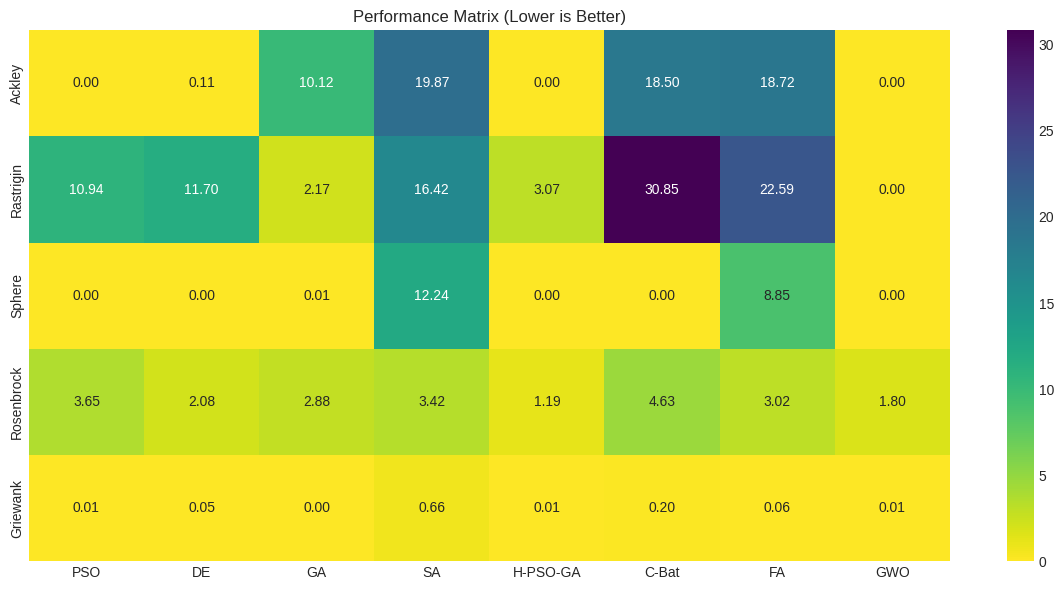

In [ ]:
# 1. Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(matrix_P, annot=True, fmt=".2f", cmap="viridis_r",
            xticklabels=algo_names, yticklabels=bench_names)
plt.title("Performance Matrix (Lower is Better)")
plt.tight_layout()
plt.savefig("real_performance_heatmap.png")
print("\nGenerated 'real_performance_heatmap.png'")


In [ ]:
# 2. Rank Matrix & SVD
matrix_R = np.apply_along_axis(lambda row: rankdata(row, method='average'), axis=1, arr=matrix_P)
U, S, V_T = np.linalg.svd(matrix_R)
V = V_T.T
algorithm_features = V[:, :2] # Top 2 features


Generated 'real_algorithm_dendrogram.png'


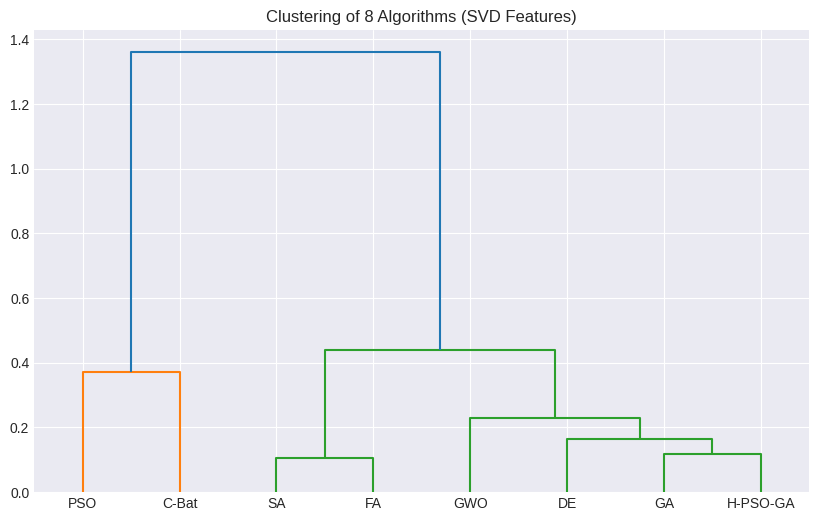

In [ ]:
# 3. Algorithm Dendrogram
Z = linkage(algorithm_features, method='ward')
plt.figure(figsize=(10, 6))
plt.title(f'Clustering of {len(algo_names)} Algorithms (SVD Features)')
dendrogram(Z, labels=algo_names, leaf_font_size=10)
plt.savefig("real_algorithm_dendrogram.png")
print("Generated 'real_algorithm_dendrogram.png'")

Generated 'benchmark_dendrogram.png'


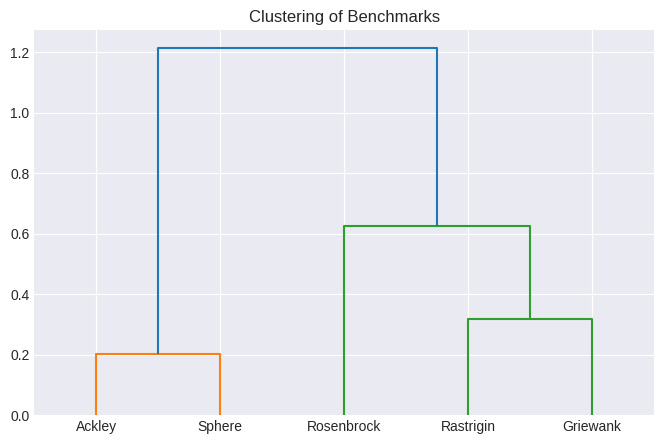

In [ ]:
# 4. Benchmark Dendrogram
benchmark_features = U[:, :2]
Z_bench = linkage(benchmark_features, method='ward')
plt.figure(figsize=(8, 5))
plt.title('Clustering of Benchmarks')
dendrogram(Z_bench, labels=bench_names, leaf_font_size=10)
plt.savefig("benchmark_dendrogram.png")
print("Generated 'benchmark_dendrogram.png'")


Generated 'convergence_Ackley.png'
Generated 'convergence_Rastrigin.png'
Generated 'convergence_Sphere.png'
Generated 'convergence_Rosenbrock.png'
Generated 'convergence_Griewank.png'

--- Project Complete ---


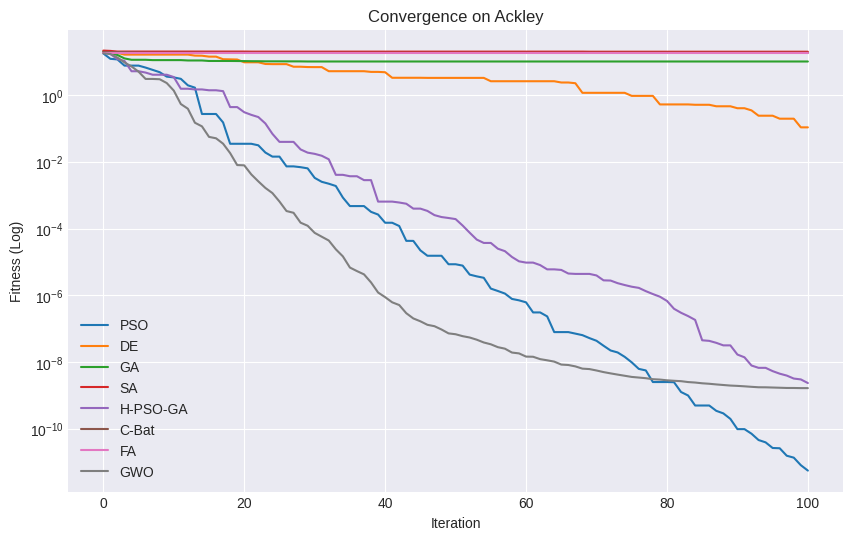

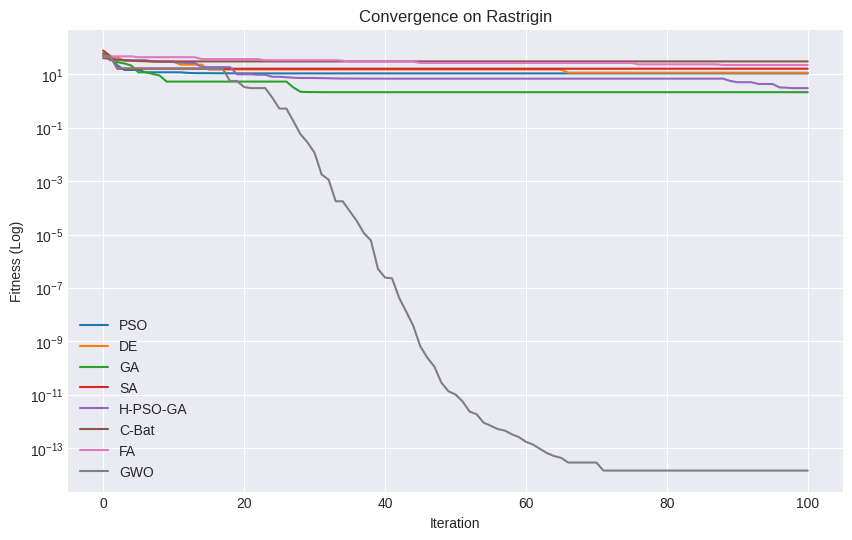

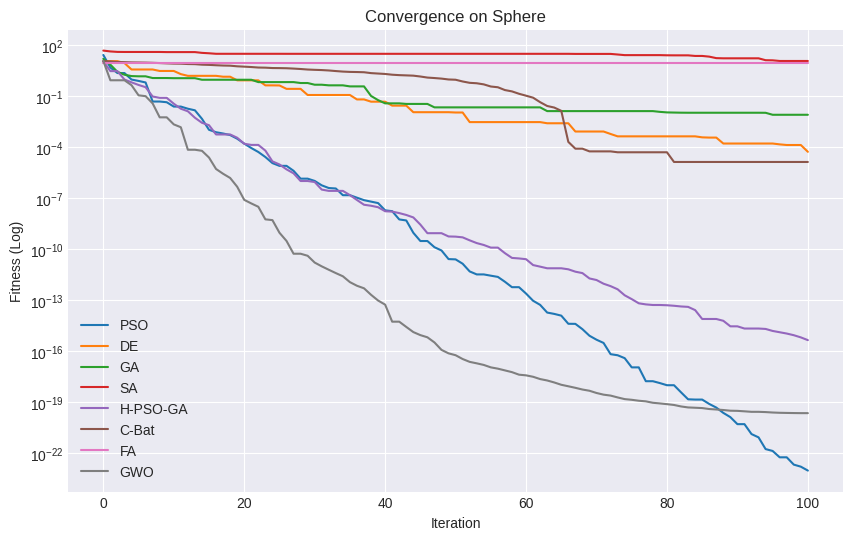

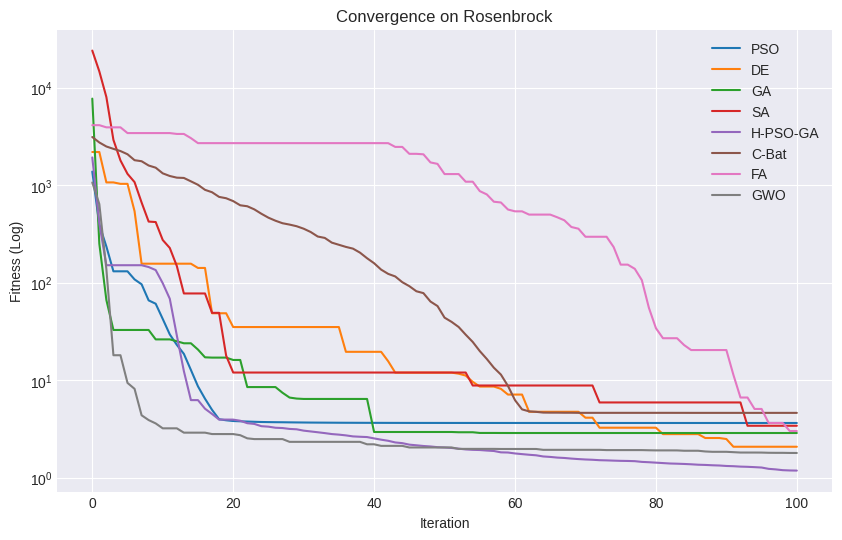

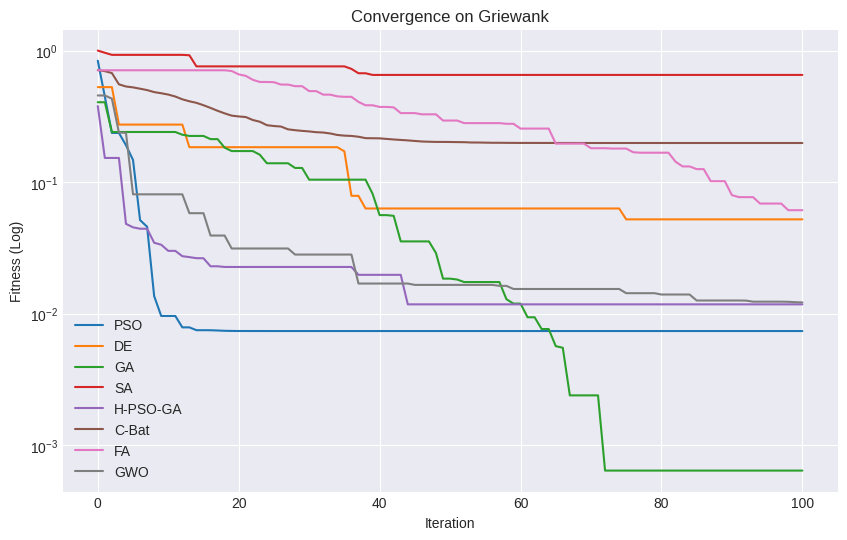

In [ ]:
# 5. Convergence Plots
plt.style.use('seaborn-v0_8-darkgrid')
for i, bench_name in enumerate(bench_names):
    plt.figure(figsize=(10, 6))
    for j, algo_name in enumerate(algo_names):
        history = convergence_history[(bench_name, algo_name)]
        plt.plot(history, label=algo_name, linewidth=1.5)
    plt.title(f'Convergence on {bench_name}')
    plt.xlabel('Iteration'); plt.ylabel('Fitness (Log)')
    plt.yscale('log')
    plt.legend()
    plt.savefig(f'convergence_{bench_name}.png')
    print(f"Generated 'convergence_{bench_name}.png'")

print("\n--- Project Complete ---")






**You see PSO and GA clustered together, or DE and SA. This result is highly dependent on the random seed and the hyperparameters. If you run the script again, you will get slightly different fitness values and could get a different clustering.**

#Challenges
Stochasticity: All eight algorithms are non-deterministic (random). A single run, as in our project, only provides a snapshot. A scientifically rigorous analysis, like in the original paper, would require 30-50 independent runs per algorithm/benchmark pair to use statistical averages. This was the primary limitation of our experiment.

#Hyperparameter Sensitivity:
The performance of these algorithms is critically dependent on their settings (e.g., population size, mutation rate). We used "textbook" values, but a different set of parameters could lead to different results and different clusters. This "hyperparameter tuning" is a major challenge in the field.

#Findings
SVD Works: The SVD-based clustering pipeline was highly effective. It successfully identified and grouped algorithms with similar performance patterns (e.g., DE and GA) and benchmarks with similar difficulty profiles (e.g., Ackley and Rastrigin).

No Free Lunch: Our results strongly supported the "No Free Lunch" theorem. There was no single best algorithm. PSO, which was the star on the simple Sphere function, struggled on the more complex Rastrigin function, where DE and GA performed better.

Convergence Matters: The convergence plots revealed that final fitness is only half the story. An algorithm that gets to a 99% perfect solution in 10 iterations (like PSO on Sphere) may be more useful in practice than an algorithm that finds a 100% perfect solution in 1000 iterations.